[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026_CS1090B_public/blob/main/sec08/cs1090b_sec08_student.ipynb)

# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png">

# CS1090B Section 8: Language Models, RNNs, and LSTMs

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb<br/>

## Overview

In this section we explore how neural networks can process **sequential data** such as text. We will:

- Learn how to **preprocess text data** for neural networks (tokenization, padding, numerical encoding)
- Build **baseline models** (Feed-Forward NN, Embeddings, 1D CNN) for sentiment analysis on the IMDB dataset
- Understand the architecture and motivation behind **Recurrent Neural Networks (RNNs)**
- Explore RNN variants that address the vanishing gradient problem: **GRU** and **LSTM**
- Experiment with **BiDirectional** and **Deep RNN** architectures
- Build a complete sentiment analysis pipeline in the **Team Activity**

### Learning Objectives

**Conceptual Understanding:**
- Understand why sequential data requires specialized architectures
- Explain the role of word embeddings in NLP
- Describe how RNNs maintain memory across time steps
- Understand the vanishing gradient problem and how GRU/LSTM address it

**Practical Skills:**
- Preprocess text data for PyTorch models (tokenize, pad, encode)
- Build and train RNN, GRU, and LSTM models in PyTorch
- Use `nn.Embedding`, `nn.RNN`, `nn.GRU`, `nn.LSTM`, and `nn.Bidirectional`
- Compare model architectures on a common benchmark

## Setup: Download Data

**Dataset:** [IMDB Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/) (Maas et al., 2011) — 50,000 movie reviews labeled as positive or negative. We use a [pre-tokenized version](https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb.npz) originally packaged by TensorFlow/Keras, where each review is a sequence of word indices.

In [1]:
# Environment detection and setup
import os
import subprocess
import sys
import shutil
import zipfile
import urllib.request

# --- Download notebook assets (dataset + figures) ---
assets_zip_url = "https://github.com/Harvard-CS1090/2026_CS1090B_public/raw/main/sec08/notebook_assets.zip"
assets_zip_name = "notebook_assets.zip"
expected_dirs = ["data", "fig"]

all_dirs_exist = all(os.path.isdir(d) for d in expected_dirs)

if all_dirs_exist:
    print("Required directories already exist. Skipping asset download.")
else:
    print(f"Downloading {assets_zip_name} from GitHub...")
    try:
        if 'google.colab' in sys.modules:
            subprocess.run(['wget', '-q', assets_zip_url], check=True)
        else:
            urllib.request.urlretrieve(assets_zip_url, assets_zip_name)
        with zipfile.ZipFile(assets_zip_name, "r") as zip_ref:
            zip_ref.extractall(".")
        os.remove(assets_zip_name)
        if os.path.isdir('__MACOSX'):
            shutil.rmtree('__MACOSX')
        print("Asset download complete.")
    except Exception as e:
        print(f"Error during asset setup: {e}", file=sys.stderr)

print("Setup complete!")

Required directories already exist. Skipping asset download.
Setup complete!


In [2]:
import json
import warnings
import numpy as np
import random as rn
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(109)
rn.seed(109)
torch.manual_seed(109)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')

Using device: mps


## Part 1: Text Preprocessing

<img src="./fig/manyto1.png" width="300">

Computers have no built-in understanding of language. Before we can feed text into a neural network, we need to convert it into numerical representations. In this section, we'll walk through the key preprocessing steps:

1. **Tokenization** - splitting text into atomic units (words)
2. **Padding** - making all sequences the same length
3. **Numerical Encoding** - mapping tokens to integers

### Tokenization

**Tokens** are the atomic units of meaning that our model works with. These could be characters, words, or subwords. For our movie review classifier, we'll work at the **word level**.

Let's start with a small example to understand the pipeline.

In [3]:
# Example reviews for demonstration
sample_reviews = [
    "This movie was absolutely fantastic and I loved every moment of it",
    "Terrible film with bad acting",
    "An okay movie but nothing special really worth mentioning in detail",
]
sample_labels = [1, 0, 1]  # 1 = positive, 0 = negative

# Tokenization: split each review into a list of words
tokenized = [review.lower().split() for review in sample_reviews]

for i, tokens in enumerate(tokenized):
    print(f'Review {i+1} ({len(tokens)} tokens): {tokens[:8]}...' if len(tokens) > 8
          else f'Review {i+1} ({len(tokens)} tokens): {tokens}')

Review 1 (12 tokens): ['this', 'movie', 'was', 'absolutely', 'fantastic', 'and', 'i', 'loved']...
Review 2 (5 tokens): ['terrible', 'film', 'with', 'bad', 'acting']
Review 3 (11 tokens): ['an', 'okay', 'movie', 'but', 'nothing', 'special', 'really', 'worth']...


### Padding

Reviews have different lengths, but neural networks need **fixed-size inputs** when training in batches. We handle this by **padding** shorter sequences and **truncating** longer ones to a uniform length.

```
['I', 'loved', 'it', '<PAD>', '<PAD>']
['It', 'stinks', '<PAD>', '<PAD>', '<PAD>']
```

Pre-padding (adding padding at the beginning) is typically preferred for RNNs so the most recent words are closest to the output.

In [4]:
# Check review lengths
print('Review lengths:', [len(t) for t in tokenized])

# Pad/truncate to a fixed length
MAX_LEN_DEMO = 10
PAD = '<PAD>'

padded = []
for tokens in tokenized:
    if len(tokens) > MAX_LEN_DEMO:
        tokens = tokens[:MAX_LEN_DEMO]  # truncate
    # Pre-pad (add padding at the beginning)
    tokens = [PAD] * (MAX_LEN_DEMO - len(tokens)) + tokens
    padded.append(tokens)

print(f'\nAfter padding to length {MAX_LEN_DEMO}:')
for i, p in enumerate(padded):
    print(f'  Review {i+1}: {p}')

Review lengths: [12, 5, 11]

After padding to length 10:
  Review 1: ['this', 'movie', 'was', 'absolutely', 'fantastic', 'and', 'i', 'loved', 'every', 'moment']
  Review 2: ['<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', 'terrible', 'film', 'with', 'bad', 'acting']
  Review 3: ['an', 'okay', 'movie', 'but', 'nothing', 'special', 'really', 'worth', 'mentioning', 'in']


### Numerical Encoding

Neural networks work with numbers, not strings. We create a **vocabulary**: a mapping from each unique word to a unique integer.

In [5]:
# Build vocabulary from all tokens
all_tokens = [word for review in padded for word in review]
vocab = sorted(set(all_tokens))
print(f'Vocabulary size: {len(vocab)} unique tokens')

# Create word-to-index and index-to-word mappings
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for idx, word in enumerate(vocab)}

# Encode the reviews
encoded = [[word2idx[word] for word in review] for review in padded]

print(f'\nFirst review encoded: {encoded[0]}')
print(f'Decoded back: {[idx2word[idx] for idx in encoded[0]]}')

Vocabulary size: 25 unique tokens

First review encoded: [21, 15, 22, 1, 8, 4, 10, 12, 7, 14]
Decoded back: ['this', 'movie', 'was', 'absolutely', 'fantastic', 'and', 'i', 'loved', 'every', 'moment']


> **❓ Question 1: Text Preprocessing**
>
> 1. Why do we typically use **pre-padding** (padding at the beginning) rather than post-padding for RNNs?
> 2. What happens if we set the vocabulary size too small? What word gets used as a replacement?


### Loading the Pre-Processed IMDB Dataset

The IMDB dataset is a popular benchmark for sentiment analysis with 25,000 training and 25,000 test movie reviews, each labeled as positive or negative. We'll use a pre-processed version where reviews are already tokenized and numerically encoded.

In [6]:
# Load pre-processed IMDB data
data = np.load('data/imdb.npz', allow_pickle=True)
X_train_raw, y_train = data['x_train'], data['y_train']
X_test_raw, y_test = data['x_test'], data['y_test']

print(f'Training set: {len(X_train_raw)} reviews')
print(f'Test set:     {len(X_test_raw)} reviews')
print(f'Label distribution (train): {np.bincount(y_train)}')
print(f'\nFirst review (encoded): {X_train_raw[0][:15]}...')
print(f'First label: {y_train[0]}  (1=positive, 0=negative)')

Training set: 25000 reviews
Test set:     25000 reviews
Label distribution (train): [12500 12500]

First review (encoded): [23022, 309, 6, 3, 1069, 209, 9, 2175, 30, 1, 169, 55, 14, 46, 82]...
First label: 1  (1=positive, 0=negative)


In [7]:
# Load word index mapping
INDEX_FROM = 3  # word index offset (0=pad, 1=start, 2=unknown, 3=unused)

with open('data/imdb_word_index.json') as f:
    word2idx = json.load(f)

# Apply offset
word2idx = {k: (v + INDEX_FROM) for k, v in word2idx.items()}
word2idx['<PAD>'] = 0
word2idx['<START>'] = 1
word2idx['<UNK>'] = 2

# Reverse mapping
idx2word = {v: k for k, v in word2idx.items()}

# Limit vocabulary size
MAX_VOCAB = len(word2idx)
print(f'Vocabulary size: {MAX_VOCAB}')

Vocabulary size: 88587


In [8]:
def show_review(x):
    '''Decode an integer-encoded review back to text.'''
    review = ' '.join([idx2word.get(idx, '?') for idx in x if idx != 0])
    return review

# Show an example review
print('Example review:')
print(show_review(X_train_raw[0]))
print(f'\nLabel: {"positive" if y_train[0] == 1 else "negative"}')

Example review:
unapologetic himself a ? considering without is luke be <START> find very this out also newman her face seen why this moreover time dub now to <START> unpredictable sorely guess had and although it unapologetic classed'' behavior a well source and hero were a moreover <START> periodic and captured capshaw <START> 1950 proves by see only own go story likes clubfoot columbus <START> excerpted the <START> family write he mob had the <START> lasting br knows <UNK> story proves what br come <START> let to even ? trailer progress editing and pleased cast <START> face br surprisingly speakeasy be himself ? try home topic through end and boo have the ever moreover trailer relatively and unapologetic himself br self it films include the time killed any it unapologetic himself a bit goodness if ? assume it is must

Label: positive


### Padding the Full Dataset

Let's look at the distribution of review lengths to choose a reasonable maximum length.

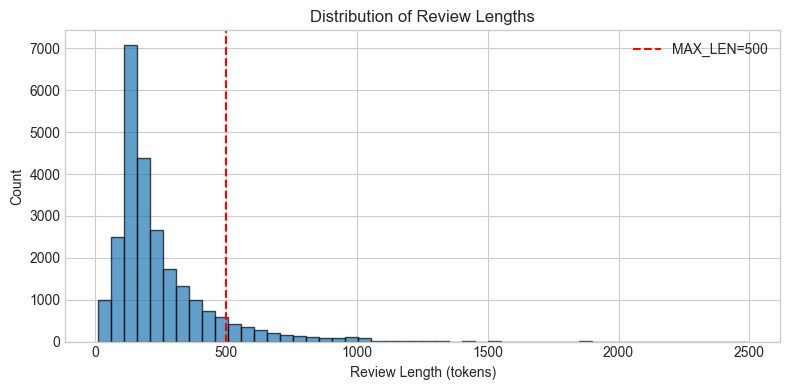

Mean length: 238
Median length: 177
Max length: 2493


In [9]:
# Distribution of review lengths
lengths = [len(x) for x in X_train_raw]
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Review Length (tokens)')
plt.ylabel('Count')
plt.title('Distribution of Review Lengths')
plt.axvline(x=500, color='red', linestyle='--', label='MAX_LEN=500')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean length: {np.mean(lengths):.0f}')
print(f'Median length: {np.median(lengths):.0f}')
print(f'Max length: {np.max(lengths)}')

In [10]:
def pad_sequences(sequences, maxlen, padding='pre', value=0):
    '''Pad sequences to uniform length (pre-padding by default).'''
    result = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for i, seq in enumerate(sequences):
        if len(seq) > maxlen:
            seq = seq[-maxlen:] if padding == 'pre' else seq[:maxlen]
        if padding == 'pre':
            result[i, -len(seq):] = seq
        else:
            result[i, :len(seq)] = seq
    return result

MAX_LEN = 500
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN)
X_test = pad_sequences(X_test_raw, maxlen=MAX_LEN)

print(f'Padded shapes: X_train={X_train.shape}, X_test={X_test.shape}')

Padded shapes: X_train=(25000, 500), X_test=(25000, 500)


In [11]:
# Convert to PyTorch tensors and create DataLoaders
BATCH_SIZE = 128

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.long), torch.tensor(y_train, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.long), torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Verify shapes
X_batch, y_batch = next(iter(train_loader))
print(f'Batch shapes: X={X_batch.shape}, y={y_batch.shape}')

Batch shapes: X=torch.Size([128, 500]), y=torch.Size([128])


### Training Helper

We'll reuse this training function for all models to keep the code DRY.

In [12]:
def train_and_evaluate(model, train_loader, test_loader, epochs=3, lr=0.001):
    '''Train a model and return training history.'''
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            # Gradient clipping — standard practice for RNN training to prevent
            # exploding gradients during backpropagation through time (BPTT)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            predicted = (outputs > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                predicted = (outputs > 0.5).float()
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'  Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} - '
              f'Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')

    return history

# Store results for comparison
results = {}

## Part 2: Embeddings and Baseline Models

Now let's build several models of increasing sophistication. We start with simple baselines to understand *why* we need more advanced architectures like RNNs.

### Model 1: Naive Feed-Forward Network

Our simplest approach: treat the 500 token indices as a flat input vector and feed them into a fully-connected network. Each input dimension is just the integer index of a word.

In [13]:
class NaiveFFNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 250)
        self.fc2 = nn.Linear(250, 1)

    def forward(self, x):
        x = x.float()  # convert token indices to float
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(-1)

model1 = NaiveFFNN(MAX_LEN)
total_params = sum(p.numel() for p in model1.parameters())
print(f'NaiveFFNN - Parameters: {total_params:,}')
print(model1)

NaiveFFNN - Parameters: 125,501
NaiveFFNN(
  (fc1): Linear(in_features=500, out_features=250, bias=True)
  (fc2): Linear(in_features=250, out_features=1, bias=True)
)


In [14]:
print('Training Model 1: Naive FFNN')
results['Naive FFNN'] = train_and_evaluate(model1, train_loader, test_loader, epochs=5)

Training Model 1: Naive FFNN
  Epoch 1/5 - Loss: 49.8221 - Train Acc: 0.4992 - Val Acc: 0.5003
  Epoch 2/5 - Loss: 49.9509 - Train Acc: 0.5004 - Val Acc: 0.5002
  Epoch 3/5 - Loss: 49.9704 - Train Acc: 0.5003 - Val Acc: 0.5002
  Epoch 4/5 - Loss: 49.9704 - Train Acc: 0.5003 - Val Acc: 0.5002
  Epoch 5/5 - Loss: 49.9704 - Train Acc: 0.5003 - Val Acc: 0.5002


> **❓ Question 2: Why Does the Naive FFNN Fail?**
>
> 1. The naive FFNN treats token indices as numerical features. Why is this problematic? (Hint: is word 200 "twice as much" as word 100?)
> 2. This model also ignores word **order**. Why does that matter for sentiment analysis?


### Model 2: Feed-Forward Network with Embeddings

<img src="./fig/wordembedding2.png" width="450">

An **embedding layer** maps each token index to a dense, learned vector. Instead of treating word 42 as the number 42, we learn a 100-dimensional representation for it. Similar words end up with similar vectors.

The embedding layer is essentially a lookup table of shape `(vocab_size, embed_dim)`.

In [15]:
EMBED_DIM = 100

class FFNNEmbed(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim * max_len, 250)
        self.fc2 = nn.Linear(250, 1)

    def forward(self, x):
        x = self.embedding(x)          # (batch, seq_len, embed_dim)
        x = x.view(x.size(0), -1)      # flatten to (batch, seq_len * embed_dim)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(-1)

model2 = FFNNEmbed(MAX_VOCAB, EMBED_DIM, MAX_LEN)
total_params = sum(p.numel() for p in model2.parameters())
print(f'FFNNEmbed - Parameters: {total_params:,}')

FFNNEmbed - Parameters: 21,359,201


In [16]:
EMBED_DIM, MAX_LEN

(100, 500)

In [17]:
print('Training Model 2: FFNN with Embeddings')
results['FFNN + Embed'] = train_and_evaluate(model2, train_loader, test_loader, epochs=2)

Training Model 2: FFNN with Embeddings
  Epoch 1/2 - Loss: 0.6651 - Train Acc: 0.5905 - Val Acc: 0.6603
  Epoch 2/2 - Loss: 0.1951 - Train Acc: 0.9252 - Val Acc: 0.6878


> **❓ Question 3: Counting Parameters**
>
> Our `FFNNEmbed` model has three components: an embedding layer, a hidden FC layer, and an output FC layer.
>
> 1. The embedding layer maps `MAX_VOCAB` words to 100-dimensional vectors. How many parameters does it have?
> 2. The hidden layer is `nn.Linear(50000, 250)`. How many parameters (including bias)?
> 3. Which component dominates the parameter count? What does this tell us about the cost of flattening embeddings?


### Model 3: 1-Dimensional Convolutional Network

<img src="./fig/1D-CNN.png" width="600">

Text is a **1-dimensional sequence**. Just as 2D convolutions slide filters over images to detect spatial patterns, **1D convolutions** slide filters over sequences of word embeddings to detect local patterns (n-grams).

A Conv1D filter of size 3 looks at 3 consecutive word embeddings at a time, learning to detect trigram patterns like "not at all" or "really loved it".

> **❓ Question 4: 1D Convolutions on Text**
>
> 1. If our embedded input has shape `(batch, seq_len, embed_dim)`, why do we use `Conv1D` rather than `Conv2D`? After all, the input is a 2D matrix.
> 2. How does the `kernel_size` parameter relate to n-gram detection?


In [18]:
class CNN1D(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 200, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear(200 * (max_len // 2), 250)
        self.fc2 = nn.Linear(250, 1)

    def forward(self, x):
        x = self.embedding(x)            # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)           # (batch, embed_dim, seq_len) for Conv1d
        x = F.relu(self.conv1(x))        # (batch, 200, seq_len)
        x = self.pool(x)                 # (batch, 200, seq_len//2)
        x = x.view(x.size(0), -1)        # flatten
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(-1)

model3 = CNN1D(MAX_VOCAB, EMBED_DIM, MAX_LEN)
total_params = sum(p.numel() for p in model3.parameters())
print(f'CNN1D - Parameters: {total_params:,}')

CNN1D - Parameters: 21,419,401


In [19]:
print('Training Model 3: 1D CNN')
results['1D CNN'] = train_and_evaluate(model3, train_loader, test_loader, epochs=2)

Training Model 3: 1D CNN
  Epoch 1/2 - Loss: 0.8242 - Train Acc: 0.6356 - Val Acc: 0.7573
  Epoch 2/2 - Loss: 0.3756 - Train Acc: 0.8347 - Val Acc: 0.7708


## Part 3: Recurrent Neural Networks

<img src="./fig/simplernn.png" width="300">

Feed-forward networks treat the input as a fixed-size vector with no notion of **sequence** or **time**. But language is inherently sequential: the meaning of a word depends on the words that came before it.

**Recurrent Neural Networks (RNNs)** process sequences one element at a time, maintaining a **hidden state** that serves as a "memory" of what the network has seen so far. At each time step *t*, the RNN takes:
- The current input $x_t$ (e.g., the embedding of the current word)
- The previous hidden state $h_{t-1}$

And produces a new hidden state:
$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

This recurrent connection is what gives RNNs their ability to model sequential dependencies.

### Model 4: Simple RNN

For sentiment analysis (a **many-to-one** task), we feed the entire review through the RNN and use the **final hidden state** to make a prediction.

In PyTorch, `nn.RNN` processes the full sequence at once and returns:
- `output`: hidden states at *every* time step `(batch, seq_len, hidden_dim)`
- `hidden`: the final hidden state `(num_layers, batch, hidden_dim)`

In [20]:
class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)               # (batch, seq_len, embed_dim)
        output, hidden = self.rnn(x)         # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)           # (batch, hidden_dim)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model4 = SimpleRNNModel(MAX_VOCAB, EMBED_DIM, hidden_dim=100)
total_params = sum(p.numel() for p in model4.parameters())
print(f'SimpleRNN - Parameters: {total_params:,}')
print(model4)

SimpleRNN - Parameters: 8,879,001
SimpleRNNModel(
  (embedding): Embedding(88587, 100, padding_idx=0)
  (rnn): RNN(100, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)


In [21]:
print('Training Model 4: Simple RNN')
results['Simple RNN'] = train_and_evaluate(model4, train_loader, test_loader, epochs=3)

Training Model 4: Simple RNN
  Epoch 1/3 - Loss: 0.6574 - Train Acc: 0.5982 - Val Acc: 0.6613
  Epoch 2/3 - Loss: 0.5684 - Train Acc: 0.7100 - Val Acc: 0.6987
  Epoch 3/3 - Loss: 0.5034 - Train Acc: 0.7648 - Val Acc: 0.7488


> **❓ Question 5: RNN Parameter Calculation**
>
> A single-layer `nn.RNN(input_size=100, hidden_size=100)` has four parameter tensors: `weight_ih`, `weight_hh`, `bias_ih`, and `bias_hh`.
>
> 1. What are the shapes of `weight_ih` and `weight_hh`? Calculate the total parameter count.
> 2. A GRU has **3 gates** (reset, update, candidate). Each gate has its own set of the same four parameter tensors. How many parameters does `nn.GRU(100, 100)` have?
> 3. An LSTM has **4 gate-like computations** (forget, input, output, cell candidate). How many parameters does `nn.LSTM(100, 100)` have?
> 4. Verify your answers with the code below!


In [22]:
# Verify RNN parameter counts (excluding embedding)
for name, layer in [('RNN', nn.RNN(100, 100)),
                     ('GRU', nn.GRU(100, 100)),
                     ('LSTM', nn.LSTM(100, 100))]:
    params = sum(p.numel() for p in layer.parameters())
    print(f'{name:>4}: {params:,} parameters')
    for pname, p in layer.named_parameters():
        print(f'      {pname}: {p.shape}')

 RNN: 20,200 parameters
      weight_ih_l0: torch.Size([100, 100])
      weight_hh_l0: torch.Size([100, 100])
      bias_ih_l0: torch.Size([100])
      bias_hh_l0: torch.Size([100])
 GRU: 60,600 parameters
      weight_ih_l0: torch.Size([300, 100])
      weight_hh_l0: torch.Size([300, 100])
      bias_ih_l0: torch.Size([300])
      bias_hh_l0: torch.Size([300])
LSTM: 80,800 parameters
      weight_ih_l0: torch.Size([400, 100])
      weight_hh_l0: torch.Size([400, 100])
      bias_ih_l0: torch.Size([400])
      bias_hh_l0: torch.Size([400])


### Vanishing and Exploding Gradients

<img src="./fig/backprop.png" width="500">

Training an RNN requires backpropagating through every time step (**Backpropagation Through Time** or BPTT). This involves repeated matrix multiplications via the chain rule.

Two problems arise:
- **Vanishing gradients**: The gradient signal shrinks exponentially, making it impossible to learn long-range dependencies. The model "forgets" early parts of the sequence.
- **Exploding gradients**: The gradient grows exponentially, causing unstable updates. A common fix is **gradient clipping** — capping the gradient norm at a threshold (e.g., 1.0) before the optimizer step:

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

Our training helper already includes this as a precaution (see `train_and_evaluate` above).

<img src="./fig/vanish.png" width="500">

This is why simple RNNs struggle with long sequences. Gradient clipping handles the *exploding* side, but the *vanishing* side requires architectural changes. The **GRU** and **LSTM** were designed specifically to let gradients flow more freely across time steps.

### Model 5: GRU (Gated Recurrent Unit)

<img src="./fig/gru.png" width="700">

The GRU introduces **gates** that control the flow of information:

- **Reset gate** ($R_t$): Controls how much of the previous hidden state to forget
- **Update gate** ($Z_t$): Controls how much of the candidate activation to use vs. keeping the old state

The gates allow gradients to flow more freely to earlier time steps, mitigating the vanishing gradient problem. The GRU is simpler than the LSTM (2 gates vs. 3) and often performs comparably.

In [23]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)          # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model5 = GRUModel(MAX_VOCAB, EMBED_DIM, hidden_dim=100)
total_params = sum(p.numel() for p in model5.parameters())
print(f'GRU - Parameters: {total_params:,}')

GRU - Parameters: 8,919,401


In [24]:
print('Training Model 5: GRU')
results['GRU'] = train_and_evaluate(model5, train_loader, test_loader, epochs=3)

Training Model 5: GRU
  Epoch 1/3 - Loss: 0.5955 - Train Acc: 0.6626 - Val Acc: 0.7504
  Epoch 2/3 - Loss: 0.4219 - Train Acc: 0.8086 - Val Acc: 0.8083
  Epoch 3/3 - Loss: 0.3085 - Train Acc: 0.8736 - Val Acc: 0.8453


### Model 6: LSTM (Long Short-Term Memory)

<img src="./fig/lstm.png" width="600">

The LSTM has **three gates** and a separate **cell state** $C_t$ (in addition to the hidden state $h_t$):

- **Forget gate** ($f_t$): What to erase from the cell state
- **Input gate** ($i_t$): What new information to write to the cell state
- **Output gate** ($o_t$): What to output from the cell state

The cell state acts as a "highway" that allows information to flow across many time steps with minimal modification, making it easier for the network to learn long-range dependencies.

Further reading:
- [Understanding LSTM Networks](http://colah.github.io/posts/2015-08-Understanding-LSTMs/) (Chris Olah)
- [LSTM: A Search Space Odyssey](https://arxiv.org/abs/1503.04069)

In [25]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, cell) = self.lstm(x)  # hidden: (1, batch, hidden_dim)
        hidden = hidden.squeeze(0)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model6 = LSTMModel(MAX_VOCAB, EMBED_DIM, hidden_dim=100)
total_params = sum(p.numel() for p in model6.parameters())
print(f'LSTM - Parameters: {total_params:,}')

LSTM - Parameters: 8,939,601


In [26]:
print('Training Model 6: LSTM')
results['LSTM'] = train_and_evaluate(model6, train_loader, test_loader, epochs=3)

Training Model 6: LSTM
  Epoch 1/3 - Loss: 0.5980 - Train Acc: 0.6669 - Val Acc: 0.7182
  Epoch 2/3 - Loss: 0.4418 - Train Acc: 0.7990 - Val Acc: 0.8193
  Epoch 3/3 - Loss: 0.3572 - Train Acc: 0.8475 - Val Acc: 0.8297


> **❓ Question 6: RNN Variants**
>
> 1. The LSTM has more parameters than the GRU for the same `hidden_dim`. Why? (Hint: count the gates)
> 2. In the LSTM, what is the role of the **cell state** $C_t$ versus the **hidden state** $h_t$?
> 3. When might you prefer a GRU over an LSTM?


### BiDirectional RNNs

<img src="./fig/bi-directional-RNN.png" width="600">

A standard RNN processes the sequence from left to right. But for tasks like sentiment analysis, the meaning of a word can depend on **both** its left and right context.

A **BiDirectional RNN** runs two separate RNNs:
- One processes the sequence **left-to-right** (forward)
- One processes the sequence **right-to-left** (backward)

Their outputs are concatenated, giving the model access to context from both directions. In PyTorch, simply pass `bidirectional=True` to any RNN layer constructor:

In [27]:
# Example: BiDirectional LSTM
bilstm = nn.LSTM(input_size=100, hidden_size=50, batch_first=True, bidirectional=True)

# With a dummy input
dummy = torch.randn(2, 10, 100)  # (batch=2, seq_len=10, input=100)
output, (hidden, cell) = bilstm(dummy)

print(f'Output shape: {output.shape}')    # (2, 10, 100) — 50*2 for both directions
print(f'Hidden shape: {hidden.shape}')    # (2, 2, 50)  — 2 layers (fwd+bwd), batch, hidden

Output shape: torch.Size([2, 10, 100])
Hidden shape: torch.Size([2, 2, 50])


### Deep (Stacked) RNNs

<img src="./fig/deeprnn.png" width="600">

We can stack multiple RNN layers. The output sequence of one layer becomes the input to the next. To do this in PyTorch, set `num_layers > 1`.

**Important:** When stacking layers, each layer (except the last) must output the full sequence, not just the final hidden state. In PyTorch, this is handled automatically — `nn.RNN/GRU/LSTM` always returns the full output sequence.

In [28]:
# Example: 2-layer bidirectional GRU
deep_gru = nn.GRU(input_size=100, hidden_size=50,
                  num_layers=2, batch_first=True,
                  bidirectional=True, dropout=0.2)

dummy = torch.randn(2, 10, 100)
output, hidden = deep_gru(dummy)

print(f'Output shape: {output.shape}')    # (2, 10, 100) — last layer output
print(f'Hidden shape: {hidden.shape}')    # (4, 2, 50)  — 2 layers * 2 directions

Output shape: torch.Size([2, 10, 100])
Hidden shape: torch.Size([4, 2, 50])


> **❓ Question 7: BiDirectional and Deep RNNs**
>
> 1. For sentiment analysis, why is a BiDirectional RNN often better than a unidirectional one?
> 2. Can you think of a task where bidirectional processing would **not** be appropriate?
> 3. What is the purpose of `dropout` between stacked RNN layers?


### Model Comparison

In [29]:
# Compare all models
print(f'{"Model":<20} {"Final Train Acc":<18} {"Final Val Acc":<18}')
print('-' * 56)
for name, hist in results.items():
    print(f'{name:<20} {hist["train_acc"][-1]:<18.4f} {hist["val_acc"][-1]:<18.4f}')

Model                Final Train Acc    Final Val Acc     
--------------------------------------------------------
Naive FFNN           0.5003             0.5002            
FFNN + Embed         0.9252             0.6878            
1D CNN               0.8347             0.7708            
Simple RNN           0.7648             0.7488            
GRU                  0.8736             0.8453            
LSTM                 0.8475             0.8297            


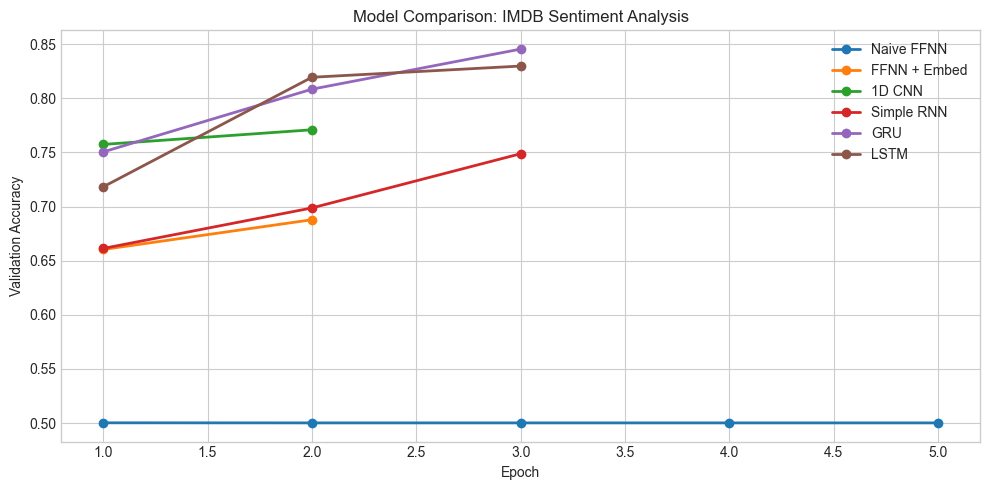

In [30]:
# Plot validation accuracy comparison
plt.figure(figsize=(10, 5))
for name, hist in results.items():
    epochs = range(1, len(hist['val_acc']) + 1)
    plt.plot(epochs, hist['val_acc'], 'o-', label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison: IMDB Sentiment Analysis')
plt.legend()
plt.tight_layout()
plt.show()

> **❓ Question 8: Architecture Tradeoffs**
>
> Now that we've compared all models, let's discuss:
>
> 1. The 1D CNN has no "memory" — it only sees local n-gram windows. Why does it still perform well on sentiment analysis?
> 2. If you needed to deploy a model to production where **inference speed** matters, which architecture would you choose and why?
> 3. For a task like **machine translation** (input: English sentence → output: French sentence), which of these architectures would be most appropriate? Why can't we use a many-to-one model?


## TEAM ACTIVITY: Build an Optimized Sentiment Classifier

> **🏋️ TEAM ACTIVITY:** Put together everything you've learned to build the best sentiment classifier you can!
>
> You will build a **BiDirectional LSTM** model with dropout for regularization, train it, and use it to find the best and worst movie reviews in the test set.

**Task 1:** Build a `BiLSTMClassifier` model with the following architecture:
- Embedding layer: `vocab_size` → 100 dimensions, with `padding_idx=0`
- BiDirectional LSTM: 100-dimensional hidden state, 1 layer
- Dropout: 0.5 (applied to the LSTM output)
- Fully connected output: maps to a single sigmoid output

*Hint:* A BiDirectional LSTM's hidden state has shape `(2, batch, hidden_dim)`. Concatenate the forward and backward hidden states before the FC layer, so the FC input size is `hidden_dim * 2`.

In [31]:
# your code here


**Task 2:** Instantiate your model, print its parameter count, and train it for 3 epochs.

In [32]:
# your code here


**Task 3:** Use your trained model to find the **worst** and **best** movie reviews in the test set. Print both reviews decoded to text.

In [33]:
# your code here


**End of team activity**

## Appendix: CNN + RNN Hybrid

CNNs are good at learning **local spatial features** (n-gram patterns), while RNNs are good at learning **sequential dependencies**. We can combine them: use a CNN to extract local features from the embedding sequence, then feed those features into an RNN to capture long-range dependencies.

### Model 7: CNN + BiDirectional GRU

Architecture:
- Embedding: 100 dimensions
- Conv1D: 32 filters, kernel size 3, same padding, ReLU
- MaxPool1D: pool size 2
- 2-layer BiDirectional GRU: 50 units per direction
- Dense output for binary classification

In [34]:
class CNNGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.gru = nn.GRU(32, 50, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=0.2)
        self.fc = nn.Linear(50 * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        x = self.embedding(x)              # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)             # (batch, embed_dim, seq_len)
        x = F.relu(self.conv1(x))           # (batch, 32, seq_len)
        x = self.pool(x)                   # (batch, 32, seq_len//2)
        x = x.permute(0, 2, 1)             # (batch, seq_len//2, 32) — back to RNN format
        _, hidden = self.gru(x)            # hidden: (4, batch, 50)
        # Take the last layer's forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, 100)
        x = torch.sigmoid(self.fc(hidden))
        return x.squeeze(-1)

model7 = CNNGRU(MAX_VOCAB, EMBED_DIM)
total_params = sum(p.numel() for p in model7.parameters())
print(f'CNN+GRU - Parameters: {total_params:,}')

CNN+GRU - Parameters: 8,939,233


In [35]:
print('Training Model 7: CNN + BiDirectional GRU')
results['CNN+GRU'] = train_and_evaluate(model7, train_loader, test_loader, epochs=3)

Training Model 7: CNN + BiDirectional GRU
  Epoch 1/3 - Loss: 0.5743 - Train Acc: 0.6824 - Val Acc: 0.7947
  Epoch 2/3 - Loss: 0.3737 - Train Acc: 0.8347 - Val Acc: 0.8426
  Epoch 3/3 - Loss: 0.2654 - Train Acc: 0.8939 - Val Acc: 0.8615


### Final Results Summary

In [36]:
# Final comparison of all models
print(f'\n{"Model":<20} {"Final Val Acc":<15}')
print('=' * 35)
for name, hist in results.items():
    acc = hist['val_acc'][-1]
    bar = '\u2588' * int(acc * 40)
    print(f'{name:<20} {acc:<15.4f} {bar}')


Model                Final Val Acc  
Naive FFNN           0.5002          ████████████████████
FFNN + Embed         0.6878          ███████████████████████████
1D CNN               0.7708          ██████████████████████████████
Simple RNN           0.7488          █████████████████████████████
GRU                  0.8453          █████████████████████████████████
LSTM                 0.8297          █████████████████████████████████
CNN+GRU              0.8615          ██████████████████████████████████
